### Loading & Testing NLP Model

In [82]:
import requests
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import json
import pandas as pd

In [83]:
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    nlp = spacy.load("en_core_web_md")

In [84]:
nlp.add_pipe("spacytextblob")

doc = nlp("Argentina faces severe economic crisis")
print(doc._.blob.polarity)  # returns -1 to +1

0.2


### Creating & Populating the Database

In [86]:
import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

def create_database(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS articles (
        article_id TEXT PRIMARY KEY,
        country TEXT,
        date TEXT,
        source_name TEXT,
        title TEXT,
        description TEXT,
        url TEXT,
        published_at TEXT
    )
    """)

    conn.commit()
    return conn, cursor

conn, cursor = create_database(DB_PATH)

In [ ]:

def insert_articles(cursor, conn, articles):

    inserted = 0

    for a in articles:

        cursor.execute("""
            INSERT OR IGNORE INTO articles (
                article_id,
                country,
                date,
                source_name,
                title,
                description,
                url,
                published_at
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            a["article_id"],
            a["country"],
            a["date"],
            a["source_name"],
            a["title"],
            a["description"],
            a["url"],
            a["published_at"]
        ))

        inserted += cursor.rowcount

    conn.commit()

    print(f"  Inserted into DB: {inserted}")

In [ ]:
#guardian
import requests

def fetch_guardian(country, begin_date, end_date, api_key):

    print("\nGUARDIAN FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print("Missing Guardian API key")
        return []

    url = "https://content.guardianapis.com/search"

    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth",
        f"{country} central bank",
        f"{country} fiscal policy"
    ]

    all_articles = []

    for q in queries:

        params = {
            "q": q,
            "from-date": begin_date,
            "to-date": end_date,
            "page-size": 200,
            "order-by": "newest",
            "show-fields": "headline,trailText",
            "api-key": api_key
        }

        print(f"  Query: {q}")

        response = requests.get(url, params=params)

        print(f"  Status code: {response.status_code}")

        if response.status_code != 200:
            print(" request failed")
            print(response.text)
            continue

        try:
            data = response.json()
        except Exception as e:
            print(f" JSON decode error: {e}")
            continue

        results = data.get("response", {}).get("results", [])

        print(f"  Articles returned: {len(results)}")

        for article in results:

            fields = article.get("fields", {})
            published_at = article.get("webPublicationDate")

            all_articles.append({
                "article_id": article.get("id"),
                "country": country,
                "date": published_at[:10] if published_at else None,
                "source_name": "The Guardian",
                "title": fields.get("headline"),
                "description": fields.get("trailText"),
                "url": article.get("webUrl"),
                "published_at": published_at
            })

    return all_articles

In [ ]:
#news
import requests

NEWSAPI_ENDPOINT = "https://newsapi.org/v2/everything"

def fetch_newsapi(country, date_str, api_key):

    print("\n NEWSAPI FETCH START")
    print(f"   Country: {country}")
    print(f"   Date: {date_str}")

    if not api_key:
        print(" Missing NewsAPI key")
        return []

    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth",
        f"{country} central bank",
        f"{country} fiscal policy"
    ]

    all_articles = []

    for query in queries:

        params = {
            "q": query,
            "from": date_str,
            "to": date_str,
            "language": "en",
            "sortBy": "publishedAt",  
            "pageSize": 50,
            "apiKey": api_key
        }

        print(f"  Query: {query}")

        response = requests.get(NEWSAPI_ENDPOINT, params=params)

        if response.status_code != 200:
            print(f"  Error: {response.text}")
            continue

        data = response.json()
        articles = data.get("articles", [])

        print(f"  Returned: {len(articles)}")

        for i, a in enumerate(articles):

            all_articles.append({
                "article_id": f"newsapi_{country}_{date_str}_{query}_{i}",
                "country": country,
                "date": date_str,
                "source_name": a.get("source", {}).get("name"),
                "title": a.get("title"),
                "description": a.get("description"),
                "url": a.get("url"),
                "published_at": a.get("publishedAt")
            })

    return all_articles

In [ ]:
#nyt
import requests

def fetch_nyt(country, begin_date, end_date, api_key):

    print("\n NYT FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print(" Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

    params = {
        "q": f"{country} (economy OR GDP OR inflation OR growth OR macro OR fiscal OR monetary)",
        "begin_date": begin_date,
        "end_date": end_date,
        "sort": "newest",
        "api-key": api_key
    }

    print(f"  Requesting NYT API...")

    response = requests.get(url, params=params)

    print(f" Status code: {response.status_code}")


    if response.status_code == 429:
        print("  RATE LIMITED — skipping request")
        return []


    if response.status_code != 200:
        print("   Request failed")
        print(response.text)
        return []

    try:
        data = response.json()
    except Exception as e:
        print(f"  JSON decode error: {e}")
        return []

    docs = data.get("response", {}).get("docs", [])

    if docs is None:
        docs = []

    print(f"  Articles returned: {len(docs)}")

    articles = []

    for doc in docs:

        published_at = doc.get("pub_date")

        article = {
            "article_id": doc.get("_id"),

            "country": country,

        
            "date": published_at[:10] if published_at else None,

            "source_name": "New York Times",

            "title": doc.get("headline", {}).get("main"),

            "description": doc.get("abstract"),

            "url": doc.get("web_url"),

            "published_at": published_at
        }

        articles.append(article)

    print(f"   Parsed articles: {len(articles)}")

    return articles

In [ ]:

import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

In [ ]:
import requests
import time

def safe_request(url, params, retries=3):

    for i in range(retries):
        try:
            response = requests.get(url, params=params, timeout=15)

        
            if response.status_code == 429:
                print("Rate limited (429). Sleeping...")
                time.sleep(5)
                continue

            return response

        except requests.exceptions.SSLError:
            print(f"SSL error (attempt {i+1}) — retrying...")
            time.sleep(2)

        except requests.exceptions.RequestException as e:
            print(f"Request error (attempt {i+1}): {e}")
            time.sleep(2)

    return None


def fetch_nyt(country, begin_date, end_date, api_key):

    print("\nNYT FETCH START")
    print(f"Country: {country}")

    if not api_key:
        print("Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"


    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth"
    ]

    all_articles = []

    for q in queries:

        params = {
            "q": q,
            "begin_date": begin_date,
            "end_date": end_date,
            "sort": "newest",
            "api-key": api_key
        }

        print(f" Query: {q}")

        response = safe_request(url, params)

        if response is None:
            print("Request failed after retries")
            continue

        if response.status_code != 200:
            print(f"Error {response.status_code}: {response.text}")
            continue

        data = response.json()
        docs = data.get("response", {}).get("docs", [])

        print(f" Articles returned: {len(docs)}")

        for doc in docs:

            published_at = doc.get("pub_date")

            all_articles.append({
                "article_id": doc.get("_id"),
                "country": country,
                "date": published_at[:10] if published_at else None,
                "source_name": "New York Times",
                "title": doc.get("headline", {}).get("main"),
                "description": doc.get("abstract"),
                "url": doc.get("web_url"),
                "published_at": published_at
            })

      
        time.sleep(1)

    return all_articles

### Querying the SQLite Database

In [144]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT DISTINCT country FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

     country
0  Argentina
1      India
2  Indonesia
3    Nigeria
4     Turkey
5    Vietnam


In [94]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT * FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

                                            article_id  country        date  \
0    business/live/2026/jan/02/uk-house-prices-drop...    India  2026-01-02   
1    business/2026/jan/06/jaguar-land-rover-sales-u...    India  2026-01-06   
2    business/live/2026/jan/06/jlr-sales-hit-by-cyb...    India  2026-01-06   
3    business/2026/jan/06/bank-of-england-venezuela...  Vietnam  2026-01-06   
4    business/2026/jan/08/shadow-fleet-ships-sancti...   Turkey  2026-01-08   
..                                                 ...      ...         ...   
574                   b91d3ab7ecea495c8dd65a57d39478db   Turkey  2026-04-22   
575                   ba0d9b11ffce9d8c9bf44b88eb4d0005   Turkey  2026-04-22   
576                   91a0820849226ce7191a4dcfe6894603   Turkey  2026-04-22   
577                   1b82a58fba64c0b5328abf4c7e21e21c   Turkey  2026-04-22   
578                   2949e8137d60035ef4e7ecbab5ce8f2d   Turkey  2026-04-22   

      source_name                                  

In [95]:

conn = sqlite3.connect("../data/articles.db")

table_name = "articles"

query = f"""
PRAGMA table_info({table_name});
"""

df_columns = pd.read_sql_query(query, conn)

print(df_columns)

conn.close()

    cid                     name  type  notnull dflt_value  pk
0     0               article_id  TEXT        0       None   1
1     1                  country  TEXT        0       None   0
2     2                     date  TEXT        0       None   0
3     3              source_name  TEXT        0       None   0
4     4                    title  TEXT        0       None   0
5     5              description  TEXT        0       None   0
6     6                      url  TEXT        0       None   0
7     7             published_at  TEXT        0       None   0
8     8          sentiment_score  REAL        0       None   0
9     9    sentiment_score_vader  REAL        0       None   0
10   10  sentiment_score_finbert  REAL        0       None   0


In [ ]:
import sqlite3
import pandas as pd
from textblob import TextBlob

conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score_vader REAL
    """)
    conn.commit()
    print("VADER column created.")
except sqlite3.OperationalError:
    print("VADER column already exists.")

df_articles = pd.read_sql_query("""
SELECT article_id, title
FROM articles
""", conn)

def sentiment_vader(text):
    if pd.isna(text):
        return None
    return TextBlob(text).sentiment.polarity

for _, row in df_articles.iterrows():
    article_id = row["article_id"]
    title = row["title"]

    score = sentiment_vader(title)

    cursor.execute("""
    UPDATE articles
    SET sentiment_score_vader = ?
    WHERE article_id = ?
    """, (score, article_id))

conn.commit()

df_vader = pd.read_sql_query("""
SELECT title, sentiment_score_vader, date, country
FROM articles
""", conn)

print(df_vader.head())

conn.close()

VADER column already exists.
                                               title  sentiment_score_vader  \
0  FTSE 100 hits 10,000 point milestone for first...                  0.625   
1  Jaguar Land Rover sales slump sharply amid US ...                 -0.125   
2  FTSE 100 posts best day in six months as stock...                  1.000   
3  Deep in the vaults: the Bank of England’s £1.4...                  0.000   
4  ‘Shadow fleet’ ships moving sanctioned oil ref...                  0.000   

         date  country  
0  2026-01-02    India  
1  2026-01-06    India  
2  2026-01-06    India  
3  2026-01-06  Vietnam  
4  2026-01-08   Turkey  


In [97]:
import sqlite3
import pandas as pd
from transformers import pipeline

finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")


conn = sqlite3.connect("../data/articles.db", timeout=30)

df_articles = pd.read_sql_query("""
SELECT article_id, title
FROM articles
WHERE title IS NOT NULL
""", conn)

conn.close() 

# SENTIMENT FUNCTION
def finbert_signed(text):
    result = finbert(text)[0]
    label = result["label"]
    score = result["score"]

    return score if label == "positive" else -score if label == "negative" else 0.0

df_articles["sentiment_score_finbert"] = df_articles["title"].apply(finbert_signed)

# REOPEN CONNECTION ONLY FOR WRITE
conn = sqlite3.connect("../data/articles.db", timeout=30)
cursor = conn.cursor()

# ensure column exists
try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score_finbert REAL
    """)
    conn.commit()
except sqlite3.OperationalError:
    pass

# BULK UPDATE
cursor.executemany("""
UPDATE articles
SET sentiment_score_finbert = ?
WHERE article_id = ?
""", list(zip(
    df_articles["sentiment_score_finbert"],
    df_articles["article_id"]
)))

conn.commit()
conn.close()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25695.07it/s]


In [98]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/articles.db")

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()

df_finbert["date"] = pd.to_datetime(df_finbert["date"])

df_finbert.head()

,date,country,sentiment_score_finbert
0,2026-01-02,India,0.879452
1,2026-01-06,India,-0.973458
2,2026-01-06,India,0.723519
3,2026-01-06,Vietnam,0.000000
4,2026-01-08,Turkey,0.000000


In [99]:
countries = ["Turkey", "India", "Indonesia", "Argentina"]

df_plot = df_finbert[df_finbert["country"].isin(countries)]

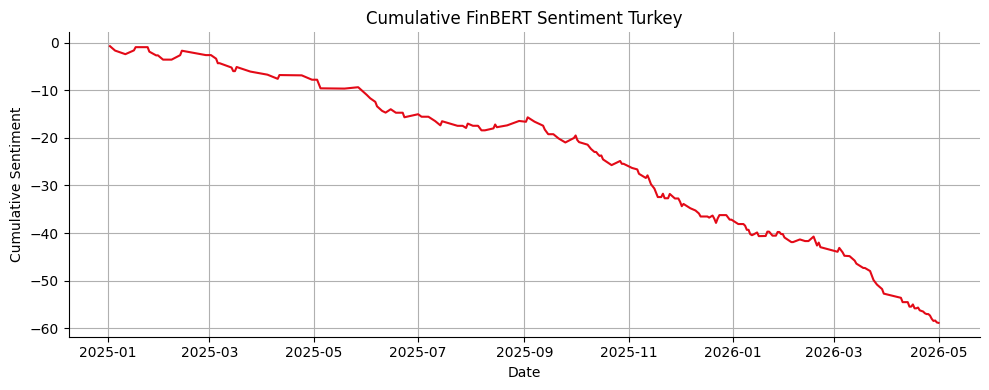

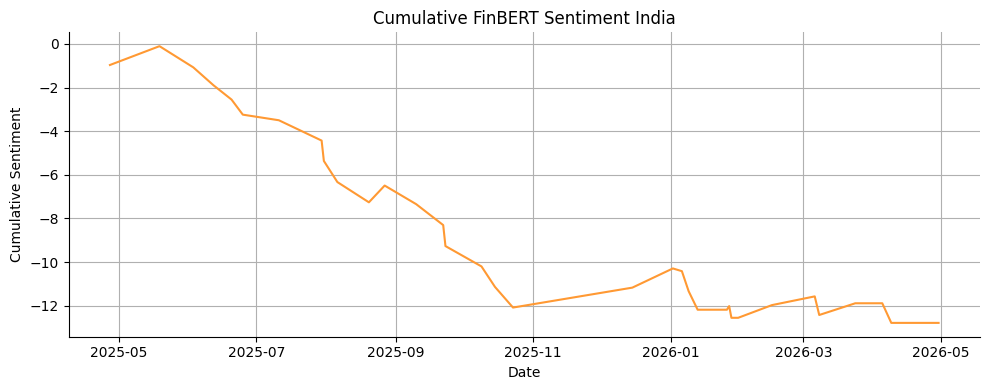

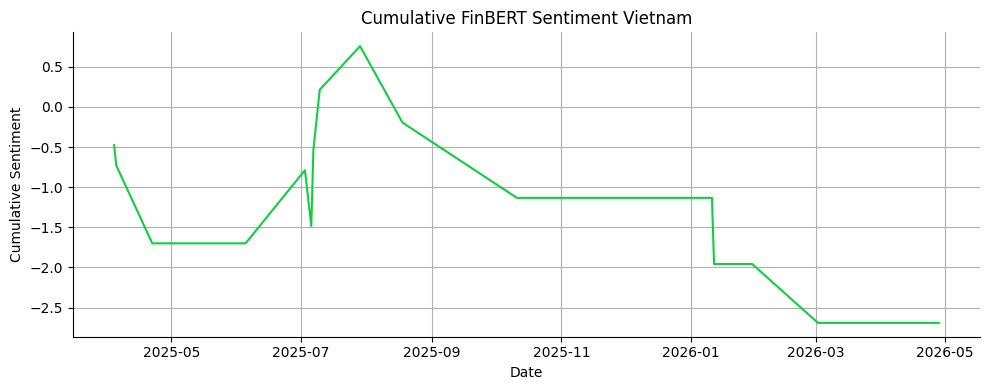

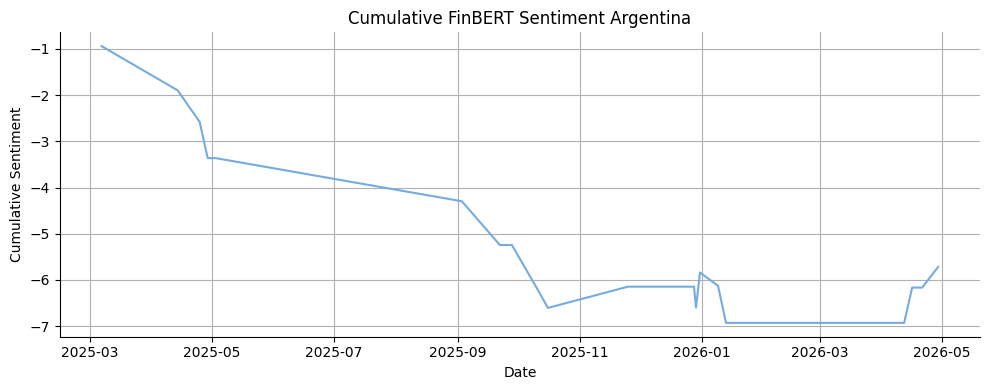

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# LOAD DATA
conn = sqlite3.connect("../data/articles.db")

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()

# CLEAN DATA
df_finbert["date"] = pd.to_datetime(df_finbert["date"])

# COLOUR MAP
colors = {
    "Turkey": "#E30A17",
    "Vietnam": "#11CE40",
    "India": "#FF9933",
    "Argentina": "#74ACDF"
}

countries = ["Turkey", "India", "Vietnam", "Argentina"]


for country in countries:

    subset = df_finbert[df_finbert["country"] == country]

    # daily average sentiment
    daily = subset.groupby("date")["sentiment_score_finbert"].mean()


    cumulative = daily.cumsum()

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        cumulative.index,
        cumulative.values,
        color=colors[country]
    )

    ax.set_title(f"Cumulative FinBERT Sentiment {country}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Sentiment")

    ax.grid(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

In [101]:
df_vader

,title,sentiment_score_vader,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625000,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125000,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000000,2026-01-08,Turkey
...,...,...,...,...
574,Temporary protected status holders add $29bn t...,0.000000,2026-04-22,Turkey
575,Strait of Hormuz is hosting gunboat diplomacy ...,0.550000,2026-04-22,Turkey
576,Zelenskyy says EU unblocking of €90bn loan for...,0.285714,2026-04-22,Turkey
577,Trump approval slips as polls show warning sig...,0.000000,2026-04-22,Turkey


In [102]:
df_plot.dtypes

date                       datetime64[us]
country                               str
sentiment_score_finbert           float64
dtype: object

In [103]:
df_plot["date"] = pd.to_datetime(df_plot["date"])

In [104]:
df_plot.dtypes

date                       datetime64[us]
country                               str
sentiment_score_finbert           float64
dtype: object

In [105]:
turkey = pd.read_csv("../data/turkey.csv")
turkey

,observation_date,CCUSMA02TRM618N
0,1957-01-01,0.000003
1,1957-02-01,0.000003
2,1957-03-01,0.000003
3,1957-04-01,0.000003
4,1957-05-01,0.000003
...,...,...
826,2025-11-01,42.240315
827,2025-12-01,42.645826
828,2026-01-01,43.161714
829,2026-02-01,43.647910


In [106]:
df_india = pd.read_csv("../data/india.csv")
df_india

,observation_date,DEXINUS
0,2021-04-26,74.75
1,2021-04-27,74.58
2,2021-04-28,74.49
3,2021-04-29,74.07
4,2021-04-30,74.00
...,...,...
1300,2026-04-20,93.13
1301,2026-04-21,93.50
1302,2026-04-22,93.79
1303,2026-04-23,94.11


In [147]:
df_indonesia = pd.read_csv("../data/indonesia.csv")
df_indonesia

,observation_date,CCUSMA02IDM618N
0,1967-01-01,137.000000
1,1967-02-01,137.000000
2,1967-03-01,137.000000
3,1967-04-01,137.000000
4,1967-05-01,137.000000
...,...,...
706,2025-11-01,16703.050000
707,2025-12-01,16707.130435
708,2026-01-01,16827.954545
709,2026-02-01,16825.700000


In [121]:
df_argentina

,observation_date,ARGCCUSMA02STM
0,2025-01-31,1041.913043
1,2025-02-28,1057.537500
2,2025-03-31,1067.505952
3,2025-04-30,1120.619318
4,2025-05-31,1150.647727
5,2025-06-30,1180.130952
6,2025-07-31,1268.184783
7,2025-08-31,1326.500000
8,2025-09-30,1401.897727
9,2025-10-31,1435.489130


In [110]:
print(df_turkey["observation_date"].diff().value_counts().head())
print(df_india["observation_date"].diff().value_counts().head())

observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64


In [111]:
for name, df in {
    "Turkey": df_turkey,
    "India": df_india,
    "Indonesia": df_indonesia,
    "Argentina": df_argentina
}.items():

    print(name)
    print(df["observation_date"].diff().value_counts().head())
    print("-" * 40)

Turkey
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
India
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
Indonesia
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------
Argentina
observation_date
31 days    7
30 days    4
28 days    1
Name: count, dtype: int64
----------------------------------------


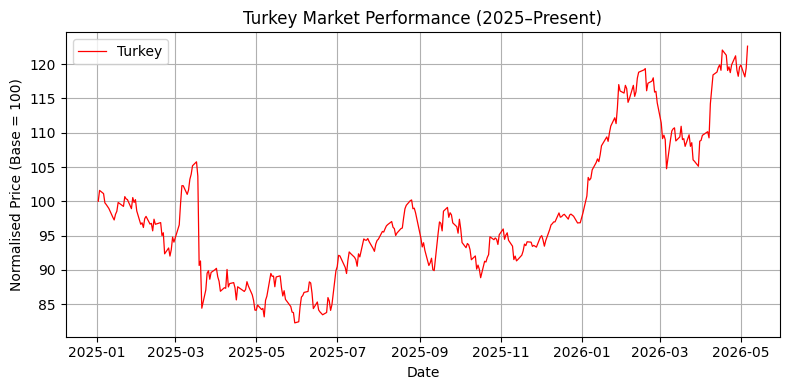

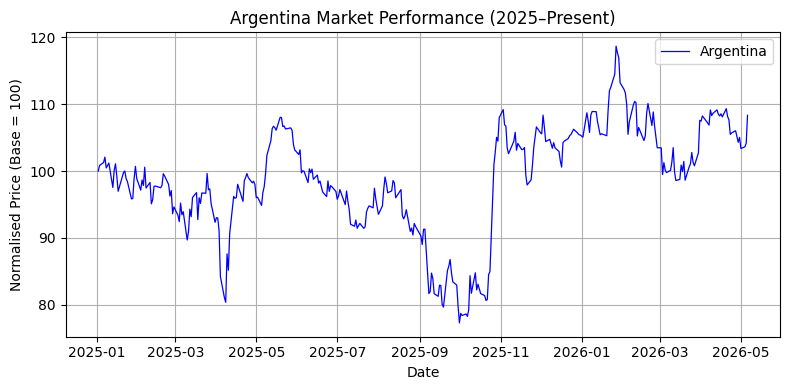

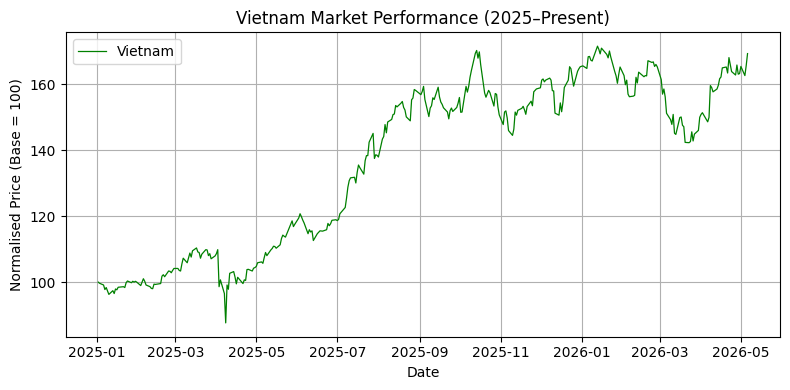

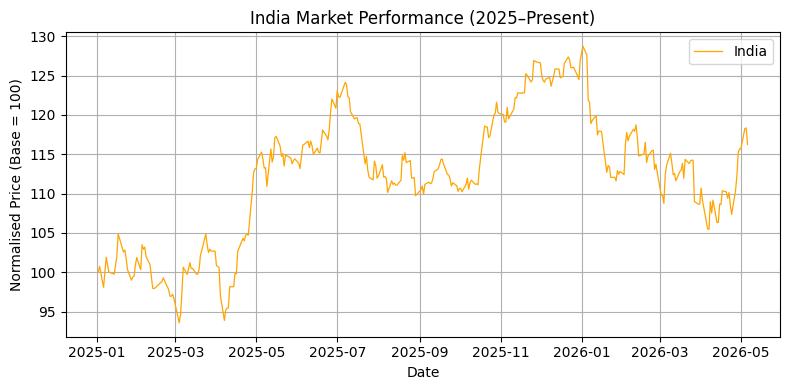

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = {
    "Turkey": "TUR",
    "Argentina": "ARGT",
    "Vietnam": "VNM",
    "India": "RELIANCE.NS"
}

start_date = "2025-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

data = pd.DataFrame()

for name, ticker in tickers.items():
    print(f"Downloading {ticker}...")

    try:
        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            progress=False,
            timeout=10
        )

        if df.empty:
            print(f"No data for {ticker}")
            continue

        if "Adj Close" in df.columns:
            data[name] = df["Adj Close"]
        else:
            data[name] = df["Close"]

    except Exception as e:
        print(f"Failed for {ticker}: {e}")

if data.empty:
    raise ValueError("No data downloaded.")

data = data.ffill()
normalized = data / data.iloc[0] * 100

colors = {
    "Turkey": "red",        
    "Argentina": "blue",   
    "Vietnam": "green",
    "India": "orange"         
}

for country in normalized.columns:
    plt.figure(figsize=(8, 4))
    
    plt.plot(
        normalized.index,
        normalized[country],
        color=colors[country],
        label=country,
        linewidth=0.9
    )
    
    plt.title(f"{country} Market Performance (2025–Present)")
    plt.xlabel("Date")
    plt.ylabel("Normalised Price (Base = 100)")
    plt.legend()
    plt.grid(True)
    
    
    plt.tight_layout()
    plt.show()


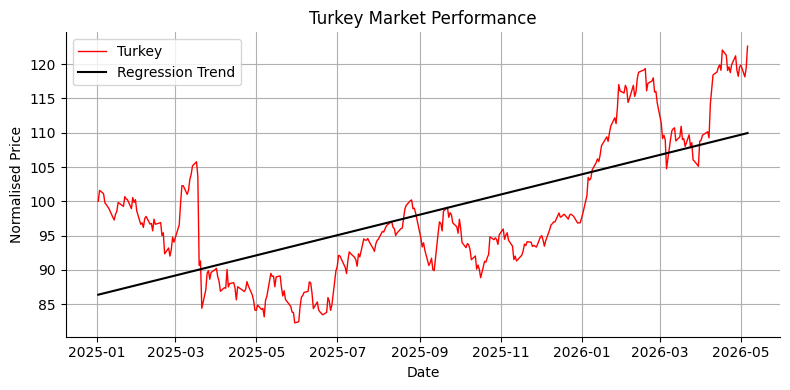

Turkey slope: 0.048185


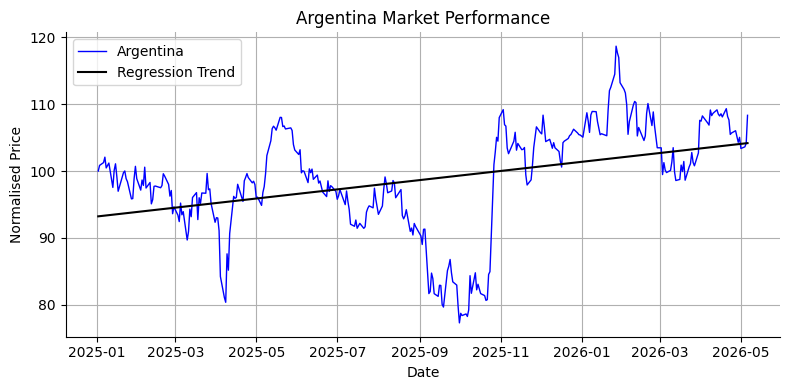

Argentina slope: 0.022399


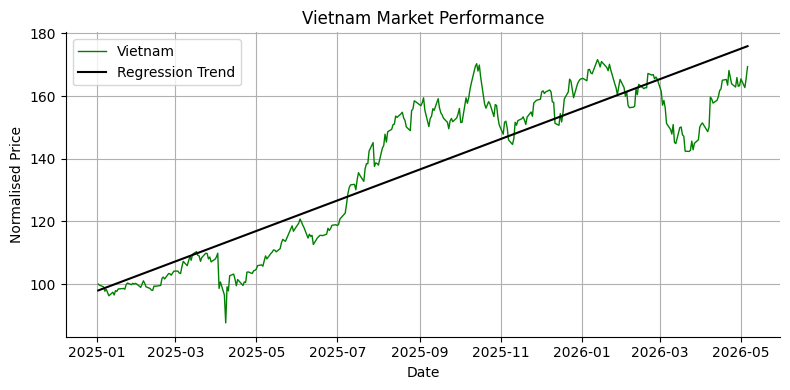

Vietnam slope: 0.159390


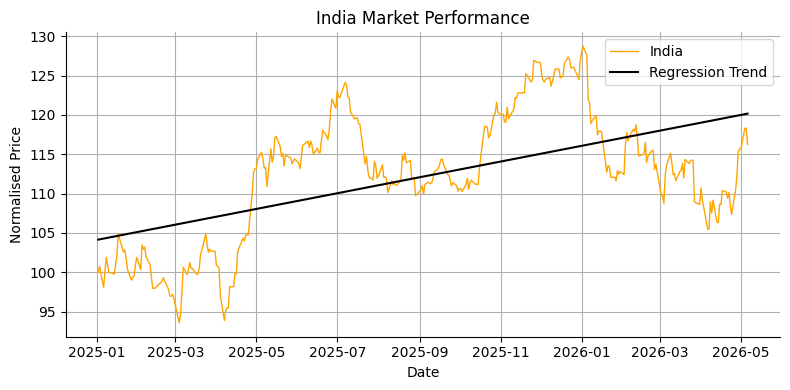

India slope: 0.032742


In [151]:
import numpy as np
import matplotlib.pyplot as plt

for country in normalized.columns:

    fig, ax = plt.subplots(figsize=(8, 4))


    x_dates = normalized.index

    # convert dates -> numeric
    x_numeric = x_dates.map(pd.Timestamp.toordinal)

    y = normalized[country]

 
    slope, intercept = np.polyfit(x_numeric, y, 1)

    trend_line = slope * x_numeric + intercept

    
    ax.plot(
        x_dates,
        y,
        color=colors[country],
        linewidth=1,
        label=f"{country}"
    )

    ax.plot(
        x_dates,
        trend_line,
        color="black",
        linestyle="-",
        linewidth=1.5,
        label="Regression Trend"
    )

    
    ax.set_title(f"{country} Market Performance")
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalised Price")

    ax.legend()
    ax.grid(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


    print(f"{country} slope: {slope:.6f}")

In [114]:
from transformers import pipeline

finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

Loading weights: 100%|██████████| 201/201 [00:00<?, ?it/s]


In [115]:
result = finbert("Turkey inflation falls faster than expected")

print(result)

[{'label': 'negative', 'score': 0.7823788523674011}]


In [116]:
conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()


query = "SELECT title FROM articles LIMIT 10"

df_test_finbert = pd.read_sql_query(query, conn)

print(df_test_finbert, "\n")

for rows in df_test_finbert["title"]:
    print(rows)
    print(finbert(rows))
    print("\n")

conn.close()

                                               title
0  FTSE 100 hits 10,000 point milestone for first...
1  Jaguar Land Rover sales slump sharply amid US ...
2  FTSE 100 posts best day in six months as stock...
3  Deep in the vaults: the Bank of England’s £1.4...
4  ‘Shadow fleet’ ships moving sanctioned oil ref...
5  Pub chain shares rise on reports of government...
6  US economy added fewer jobs than forecast in D...
7  High costs, falling returns: what could go wro...
8  Why Russia’s economy is unlikely to collapse e...
9  Trump move for Venezuela’s resources likely to... 

FTSE 100 hits 10,000 point milestone for first time, after best year of gains since 2009 – as it happened
[{'label': 'positive', 'score': 0.8794516324996948}]


Jaguar Land Rover sales slump sharply amid US tariffs and cyber-attack
[{'label': 'negative', 'score': 0.9734575748443604}]


FTSE 100 posts best day in six months as stock market rally continues – as it happened
[{'label': 'positive', 'score': 0.7235189

In [117]:
import sqlite3

conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()

cursor.execute("PRAGMA table_info(articles)")

for row in cursor.fetchall():
    print(row)

conn.close()

(0, 'article_id', 'TEXT', 0, None, 1)
(1, 'country', 'TEXT', 0, None, 0)
(2, 'date', 'TEXT', 0, None, 0)
(3, 'source_name', 'TEXT', 0, None, 0)
(4, 'title', 'TEXT', 0, None, 0)
(5, 'description', 'TEXT', 0, None, 0)
(6, 'url', 'TEXT', 0, None, 0)
(7, 'published_at', 'TEXT', 0, None, 0)
(8, 'sentiment_score', 'REAL', 0, None, 0)
(9, 'sentiment_score_vader', 'REAL', 0, None, 0)
(10, 'sentiment_score_finbert', 'REAL', 0, None, 0)


In [118]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/articles.db")

check_query = """
SELECT title, sentiment_score_vader, date, country
FROM articles
"""

df = pd.read_sql_query(check_query, conn)

conn.close()

df

,title,sentiment_score_vader,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625000,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125000,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000000,2026-01-08,Turkey
...,...,...,...,...
574,Temporary protected status holders add $29bn t...,0.000000,2026-04-22,Turkey
575,Strait of Hormuz is hosting gunboat diplomacy ...,0.550000,2026-04-22,Turkey
576,Zelenskyy says EU unblocking of €90bn loan for...,0.285714,2026-04-22,Turkey
577,Trump approval slips as polls show warning sig...,0.000000,2026-04-22,Turkey


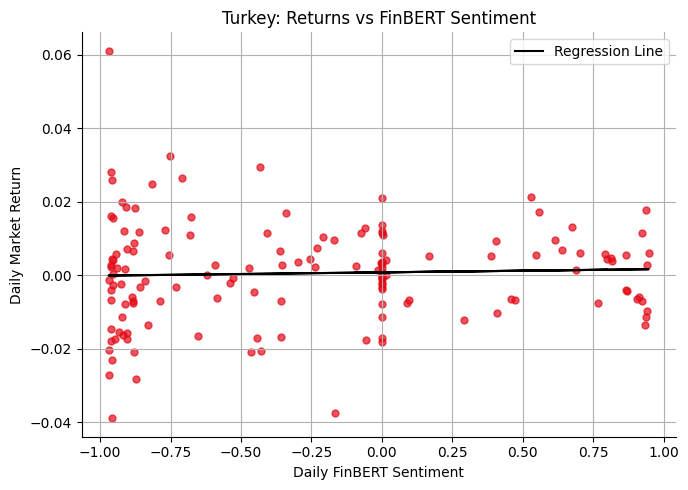


Turkey
----------------------------------------
Slope (β): 0.000897
Correlation: 0.0414


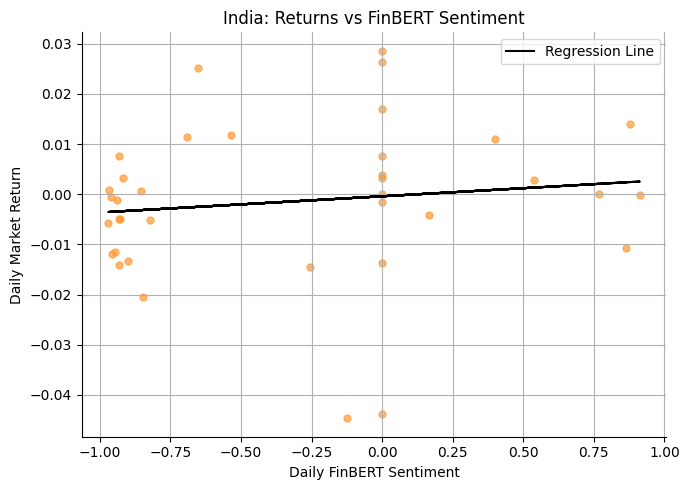


India
----------------------------------------
Slope (β): 0.003227
Correlation: 0.1284


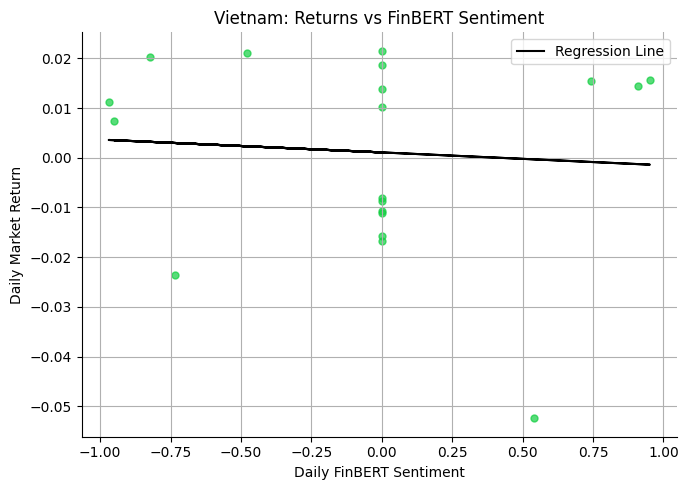


Vietnam
----------------------------------------
Slope (β): -0.002586
Correlation: -0.0745


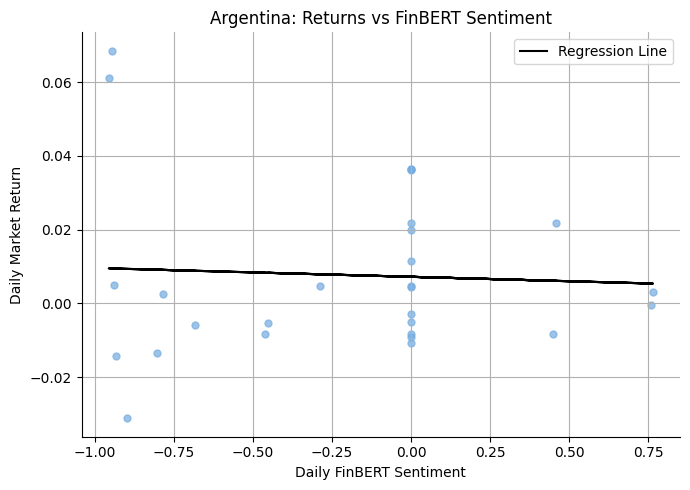


Argentina
----------------------------------------
Slope (β): -0.002393
Correlation: -0.0531


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3


returns = data.pct_change().dropna()

#

conn = sqlite3.connect("../data/articles.db")

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()


df_finbert["date"] = pd.to_datetime(df_finbert["date"])



colors = {
    "Turkey": "#E30A17",
    "Vietnam": "#11CE40",
    "India": "#FF9933",
    "Argentina": "#74ACDF"
}

countries = ["Turkey", "India", "Vietnam", "Argentina"]



for country in countries:


    sentiment = (
        df_finbert[df_finbert["country"] == country]
        .groupby("date")["sentiment_score_finbert"]
        .mean()
        .reset_index()
    )

    sentiment.columns = ["date", "sentiment"]

    market = returns[[country]].reset_index()

    market.columns = ["date", "returns"]

    merged = pd.merge(
        sentiment,
        market,
        on="date",
        how="inner"
    )

  
    merged = merged.dropna()

    if len(merged) < 5:
        print(f"Not enough data for {country}")
        continue


    x = merged["sentiment"]
    y = merged["returns"]

    slope, intercept = np.polyfit(x, y, 1)

    regression_line = slope * x + intercept

    correlation = np.corrcoef(x, y)[0, 1]


    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        x,
        y,
        color=colors[country],
        alpha=0.7,
        s=25
    )

    # regression line
    ax.plot(
        x,
        regression_line,
        color="black",
        linestyle="-",
        linewidth=1.5,
        label="Regression Line"
    )


    ax.set_title(f"{country}: Returns vs FinBERT Sentiment")

    ax.set_xlabel("Daily FinBERT Sentiment")
    ax.set_ylabel("Daily Market Return")

    ax.grid(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n{country}")
    print("-" * 40)
    print(f"Slope (β): {slope:.6f}")
    print(f"Correlation: {correlation:.4f}")

In [ ]:
import pandas as pd
import numpy as np


df = pd.merge(sentiment_df, returns_df, on="date", how="inner")

results = []

def compute_stats(x, y):
    corr = x.corr(y)
    r2 = corr ** 2
    return corr, r2


for lag in range(0, 11):
    temp = df.copy()
    
    temp["sentiment_lag"] = temp["sentiment"].shift(lag)
    temp_clean = temp.dropna()
    
    corr, r2 = compute_stats(temp_clean["sentiment_lag"], temp_clean["returns"])
    
    results.append({
        "direction": "sentiment_lag",
        "lag": lag,
        "correlation": corr,
        "R2": r2
    })


for lag in range(0, 11):
    temp = df.copy()
    
    temp["returns_lag"] = temp["returns"].shift(lag)
    temp_clean = temp.dropna()
    
    corr, r2 = compute_stats(temp_clean["sentiment"], temp_clean["returns_lag"])
    
    results.append({
        "direction": "returns_lag",
        "lag": lag,
        "correlation": corr,
        "R2": r2
    })


results_df = pd.DataFrame(results)

print("\n=== Full Results Table ===")
print(results_df.sort_values(by="correlation", ascending=False))

# Best lag (by absolute correlation)
best = results_df.loc[results_df["correlation"].abs().idxmax()]

print("\n=== BEST LAG ===")
print(best)


=== Full Results Table ===
        direction  lag  correlation        R2
21    returns_lag   10     0.288704  0.083350
18    returns_lag    7     0.273915  0.075030
6   sentiment_lag    6     0.206988  0.042844
17    returns_lag    6     0.181252  0.032852
9   sentiment_lag    9     0.135074  0.018245
14    returns_lag    3     0.100504  0.010101
8   sentiment_lag    8     0.054536  0.002974
1   sentiment_lag    1     0.028904  0.000835
20    returns_lag    9    -0.008750  0.000077
7   sentiment_lag    7    -0.044472  0.001978
0   sentiment_lag    0    -0.062120  0.003859
11    returns_lag    0    -0.062120  0.003859
10  sentiment_lag   10    -0.067528  0.004560
13    returns_lag    2    -0.093131  0.008673
4   sentiment_lag    4    -0.110067  0.012115
3   sentiment_lag    3    -0.139634  0.019498
2   sentiment_lag    2    -0.202224  0.040894
5   sentiment_lag    5    -0.208810  0.043602
15    returns_lag    4    -0.217546  0.047326
19    returns_lag    8    -0.223086  0.049768
12    

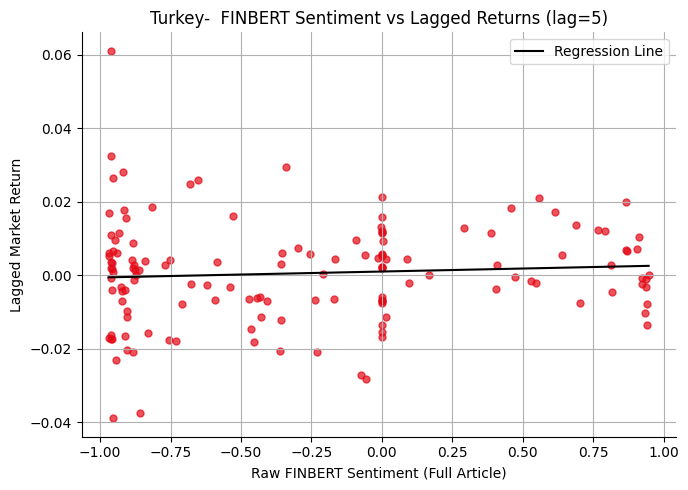


Turkey
----------------------------------------
Correlation: 0.0746
Slope (β): 0.001632


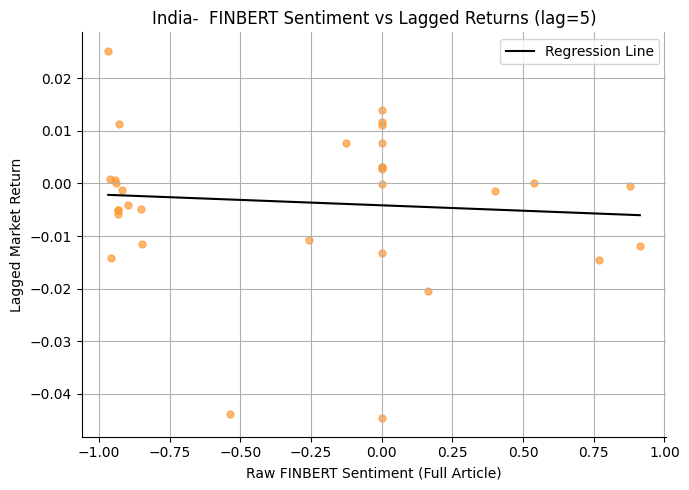


India
----------------------------------------
Correlation: -0.0871
Slope (β): -0.002056


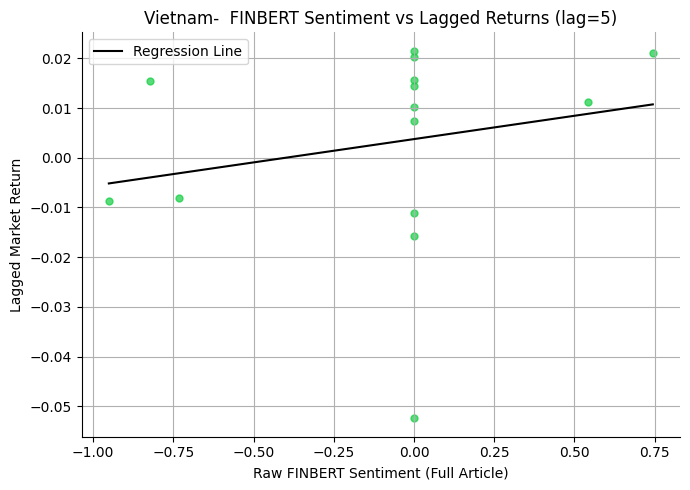


Vietnam
----------------------------------------
Correlation: 0.2152
Slope (β): 0.009387


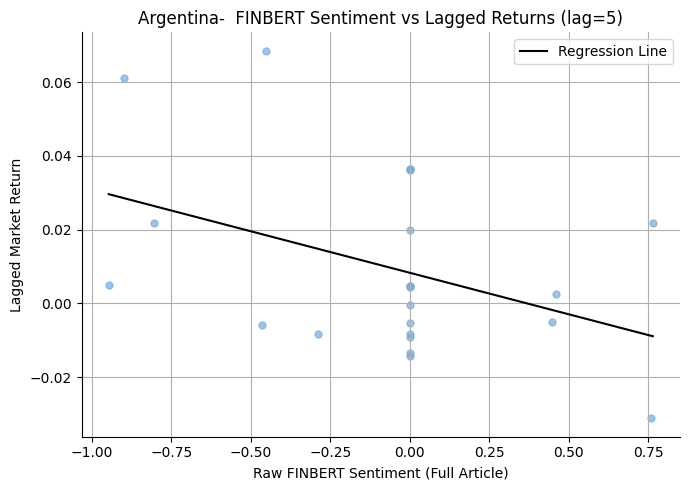


Argentina
----------------------------------------
Correlation: -0.4052
Slope (β): -0.022519


In [161]:

BEST_LAG = 5

for country in countries:

   
    sentiment = (
        df_finbert[df_finbert["country"] == country]
        .groupby("date")["sentiment_score_finbert"]
        .mean()
        .reset_index()
    )

    sentiment.columns = ["date", "sentiment"]


    if country not in returns.columns:
        print(f"Skipping {country} (missing in returns)")
        continue

    market = returns[[country]].reset_index()
    market.columns = ["date", "returns"]


    merged = pd.merge(sentiment, market, on="date", how="inner").dropna()

    if len(merged) < 10:
        print(f"Not enough data for {country}")
        continue


    merged["returns_lagged"] = merged["returns"].shift(BEST_LAG)

    final = merged[["sentiment", "returns_lagged"]].dropna()

    x = final["sentiment"]
    y = final["returns_lagged"]

   
    slope, intercept = np.polyfit(x, y, 1)
    correlation = np.corrcoef(x, y)[0, 1]

    # regression line
    x_sorted = np.sort(x)
    regression_line = slope * x_sorted + intercept

    

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        x,
        y,
        color=colors[country],
        alpha=0.7,
        s=25
    )

    ax.plot(
        x_sorted,
        regression_line,
        color="black",
        linewidth=1.5,
        label="Regression Line"
    )

    # ---------------------------------------------
    # LABELS
    # ---------------------------------------------
    ax.set_title(f"{country}-  FINBERT Sentiment vs Lagged Returns (lag={BEST_LAG})")
    ax.set_xlabel("Raw FINBERT Sentiment (Full Article)")
    ax.set_ylabel("Lagged Market Return")

    ax.grid(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend()

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------
    # RESULTS
    # ---------------------------------------------
    print(f"\n{country}")
    print("-" * 40)
    print(f"Correlation: {correlation:.4f}")
    print(f"Slope (β): {slope:.6f}")

In [128]:
import sqlite3

conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN article_text TEXT
    """)

    conn.commit()
    print("article_text column created.")

except sqlite3.OperationalError:
    print("article_text column already exists.")

conn.close()

article_text column created.


In [ ]:
import sqlite3
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time


conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()


df_articles = pd.read_sql_query("""

SELECT article_id, url

FROM articles

WHERE url IS NOT NULL
AND article_text IS NULL

""", conn)

print(f"Articles to scrape: {len(df_articles)}")


headers = {
    "User-Agent": "Mozilla/5.0"
}


def scrape_article_text(url):

    try:

        response = requests.get(
            url,
            headers=headers,
            timeout=10
        )

        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.text, "html.parser")

    
        paragraphs = soup.find_all("p")

        text = " ".join(
            p.get_text(strip=True)
            for p in paragraphs
        )

        
        if len(text) < 200:
            return None

        return text

    except Exception as e:
        print(f"Scrape failed: {e}")
        return None


success = 0
failed = 0

for _, row in df_articles.iterrows():

    article_id = row["article_id"]
    url = row["url"]

    print(f"Scraping: {url}")

    text = scrape_article_text(url)

    if text is not None:

        cursor.execute("""

        UPDATE articles
        SET article_text = ?
        WHERE article_id = ?

        """, (text, article_id))

        success += 1

    else:
        failed += 1

    
    time.sleep(1)


conn.commit()

print("\nscraping complete")
print(f"Success: {success}")
print(f"Failed: {failed}")

conn.close()

Articles to scrape: 579
Scraping: https://www.theguardian.com/business/live/2026/jan/02/uk-house-prices-drop-december-lidl-christmas-sales-ftse-business-live-news
Scraping: https://www.theguardian.com/business/2026/jan/06/jaguar-land-rover-sales-us-tariffs-cyber-attack-shares-tata-motors
Scraping: https://www.theguardian.com/business/live/2026/jan/06/jlr-sales-hit-by-cyber-attack-next-beats-christmas-sales-expectations-uk-services-sector-stock-market-business-live
Scraping: https://www.theguardian.com/business/2026/jan/06/bank-of-england-venezuelan-gold-nicolas-maduro-us-uk
Scraping: https://www.theguardian.com/business/2026/jan/08/shadow-fleet-ships-sanctioned-oil-reflagged-russia-lloyds-list-analysis
Scraping: https://www.theguardian.com/business/live/2026/jan/08/marks-spencer-tesco-greggs-christmas-trading-house-prices-stock-markets-business-live-news-updates
Scraping: https://www.theguardian.com/business/live/2026/jan/09/rio-tinto-glencore-merger-talks-mining-sainsbury-us-jobs-repo

In [ ]:
import sqlite3
import pandas as pd
from transformers import pipeline

finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()


try:
    cursor.execute("""

    ALTER TABLE articles
    ADD COLUMN sentiment_fulltext_finbert REAL

    """)

    conn.commit()

except sqlite3.OperationalError:
    print("Column already exists.")


df_articles = pd.read_sql_query("""

SELECT article_id, article_text

FROM articles

WHERE article_text IS NOT NULL

""", conn)


def finbert_signed(text):

    try:

    
        text = text[:2000]

        result = finbert(text)[0]

        label = result["label"]
        score = result["score"]

        if label == "positive":
            return score

        elif label == "negative":
            return -score

        else:
            return 0.0

    except Exception:
        return None


df_articles["sentiment_fulltext_finbert"] = (
    df_articles["article_text"]
    .apply(finbert_signed)
)



cursor.executemany("""

UPDATE articles
SET sentiment_fulltext_finbert = ?
WHERE article_id = ?

""", list(zip(
    df_articles["sentiment_fulltext_finbert"],
    df_articles["article_id"]
)))

conn.commit()

print("Full article sentiment complete.")

conn.close()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8864.00it/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (594 > 512). Running this sequence through the model will result in indexing errors


Full article sentiment complete.


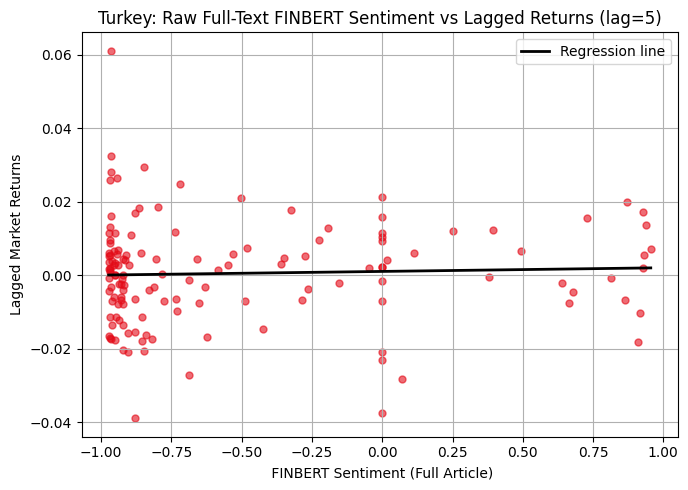


Turkey
----------------------------------------
Correlation: 0.0423
R²: 0.0018
Slope (β): 0.001001


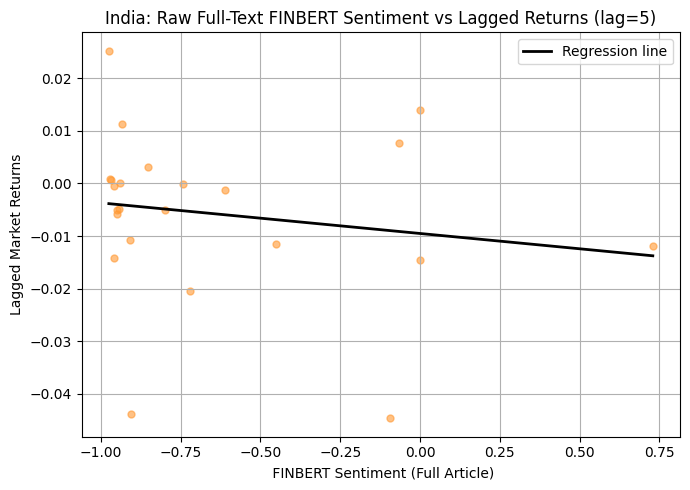


India
----------------------------------------
Correlation: -0.1676
R²: 0.0281
Slope (β): -0.005822


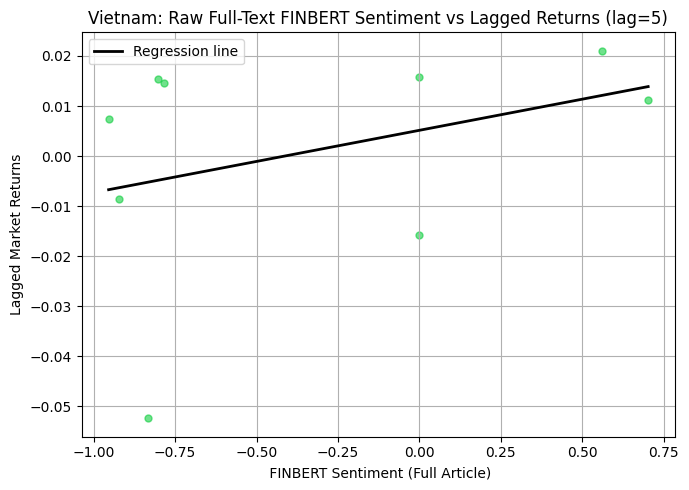


Vietnam
----------------------------------------
Correlation: 0.3514
R²: 0.1235
Slope (β): 0.012446


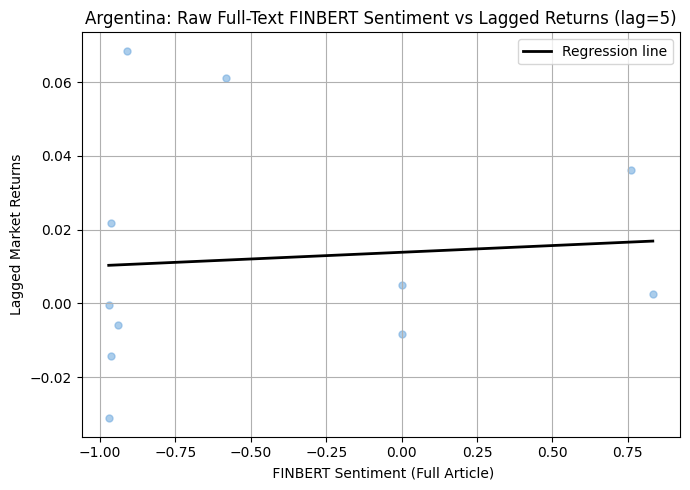


Argentina
----------------------------------------
Correlation: 0.0824
R²: 0.0068
Slope (β): 0.003647


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Web Scraped contents of the article

BEST_LAG = 5

countries = ["Turkey", "India", "Vietnam", "Argentina"]

colors = {
    "Turkey": "#E30A17",
    "India": "#FF9933",
    "Vietnam": "#11CE40",
    "Argentina": "#74ACDF"
}


conn = sqlite3.connect("../data/articles.db")

df = pd.read_sql_query("""
SELECT date, country, sentiment_fulltext_finbert
FROM articles
WHERE sentiment_fulltext_finbert IS NOT NULL
""", conn)

conn.close()

df["date"] = pd.to_datetime(df["date"])


for country in countries:
    sentiment = (
        df[df["country"] == country]
        .groupby("date")["sentiment_fulltext_finbert"]
        .mean()
        .reset_index()
    )

    sentiment.columns = ["date", "sentiment"]

    if country not in returns.columns:
        print(f"Skipping {country} (missing in returns)")
        continue

    market = returns[[country]].reset_index()
    market.columns = ["date", "returns"]

    merged = pd.merge(sentiment, market, on="date", how="inner").dropna()

    if len(merged) < 10:
        print(f"Not enough data for {country}")
        continue

    merged["returns_lagged"] = merged["returns"].shift(BEST_LAG)

    final = merged[["sentiment", "returns_lagged"]].dropna()

    x = final["sentiment"]
    y = final["returns_lagged"]

    slope, intercept = np.polyfit(x, y, 1)

    correlation = np.corrcoef(x, y)[0, 1]
    r2 = correlation ** 2

    x_sorted = np.sort(x)


    plt.figure(figsize=(7,5))

    plt.scatter(
        x,
        y,
        color=colors[country],
        alpha=0.6,
        s=25
    )

    plt.plot(
        x_sorted,
        slope * x_sorted + intercept,
        color="black",
        linewidth=2,
        label="Regression line"
    )

    plt.title(
        f"{country} - FINBERT Sentiment vs Lagged Returns (lag={BEST_LAG})"
    )

    plt.xlabel(" FINBERT Sentiment (Full Article)")
    plt.ylabel("Lagged Market Returns")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n{country}")
    print("-" * 40)
    print(f"Correlation: {correlation:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Slope (β): {slope:.6f}")